In [1]:
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import boto3

# Read All History

In [2]:
df0 = pd.read_csv('history-all.csv', parse_dates=['Datetime'])
# df0

In [3]:
s0 = df0.set_index('Datetime')['CPM']
s0.index = s0.index.round('min')
# s0

In [4]:
index = pd.date_range(
    start=s0.index.min(),
    end=s0.index.max(),
    freq='1min',
    name='Datetime')
all_series = s0.reindex(index)
all_series

Datetime
2025-06-22 11:32:00     7.0
2025-06-22 11:33:00    11.0
2025-06-22 11:34:00    17.0
2025-06-22 11:35:00    11.0
2025-06-22 11:36:00    13.0
                       ... 
2025-07-13 07:08:00    12.0
2025-07-13 07:09:00    12.0
2025-07-13 07:10:00    13.0
2025-07-13 07:11:00    10.0
2025-07-13 07:12:00     9.0
Freq: min, Name: CPM, Length: 29981, dtype: float64

In [5]:
all_title = all_series.index[0].strftime('All · Honolulu')
all_title

'All · Honolulu'

# Plot All Histogram

In [6]:
all_histogram = all_series.value_counts(normalize=True).sort_index().rename('PMF')
# all_histogram

In [7]:
x = pd.Index(range(30 + 1), name='CPM')
y = poisson.pmf(x, all_series.mean())
all_poisson = pd.Series(y, index=x, name='PMF')
# all_poisson

In [8]:
stats = (
    f'x̄ = {all_series.mean():.3f}\n'
    f'σ² = {all_series.var():.3f}\n'
    f'min = {all_series.min():.0f}\n'
    f'max = {all_series.max():.0f}')

Text(0, 0.5, 'Probability')

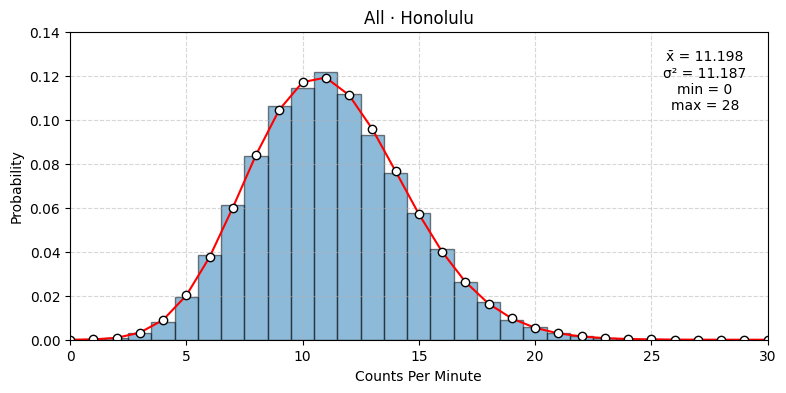

In [9]:
fig_b, ax = plt.subplots(1, 1, figsize=(9, 4))

ax.bar(all_histogram.index, all_histogram.values,
    width=1.0, align='center', color='#1f77b4', alpha=0.5, edgecolor='black')
ax.plot(all_poisson,
    color='red', marker='o', markerfacecolor='white', markeredgecolor='black')
ax.text(0.91, 0.84, stats,
    transform=ax.transAxes, va='center', ha='center')

ax.set_xlim(0, 30)
ax.set_ylim(0, 0.14)
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title(all_title)
ax.set_xlabel('Counts Per Minute')
ax.set_ylabel('Probability')

<Axes: xlabel='Datetime'>

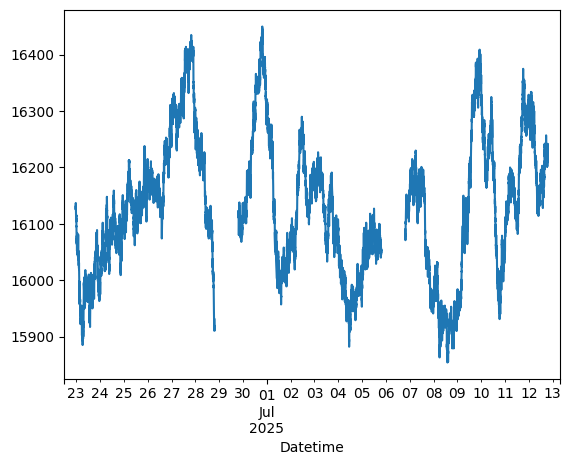

In [22]:
s0 = all_series.rolling(60*24, center=True).sum()
s0.plot()

<Axes: xlabel='Datetime'>

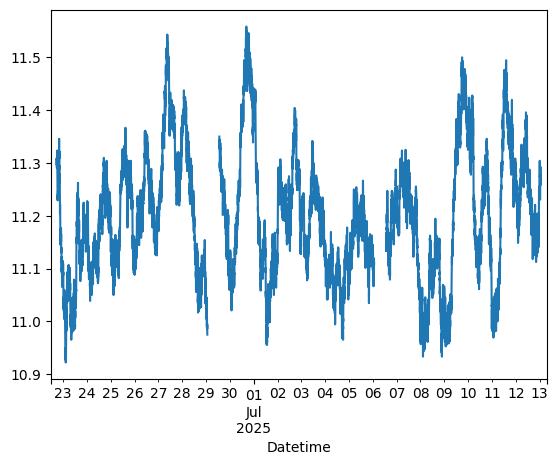

In [17]:
s1 = all_series.rolling(12*60, center=True).mean()
s1.plot()

<Axes: xlabel='Datetime'>

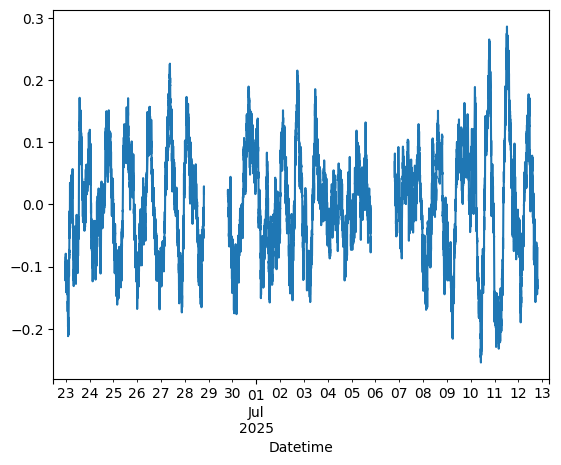

In [18]:
(s1 - s0).plot()

<Axes: xlabel='Datetime'>

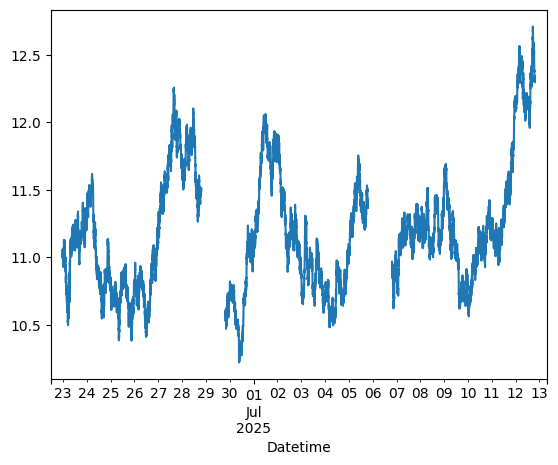

In [20]:
s3 = all_series.rolling(60*24, center=True).var()
s3.plot()

<Axes: xlabel='Datetime'>

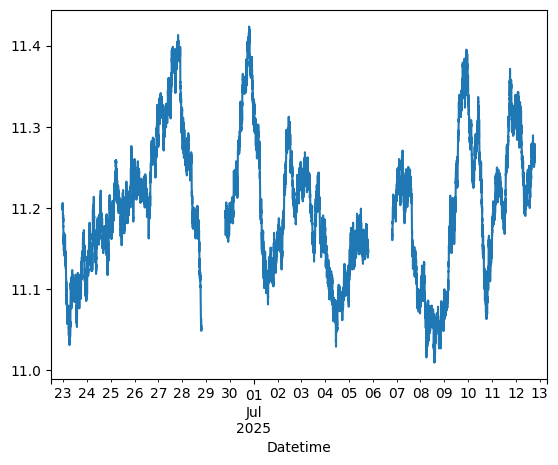

In [21]:
s0 = all_series.rolling(60*24, center=True).mean()
s0.plot()